WORLD HAPPINESS KPI
Total Records: 1502
Minimum Happiness Score: 1.72
Maximum Happiness Score: 7.74
Average Happiness Score: 5.78


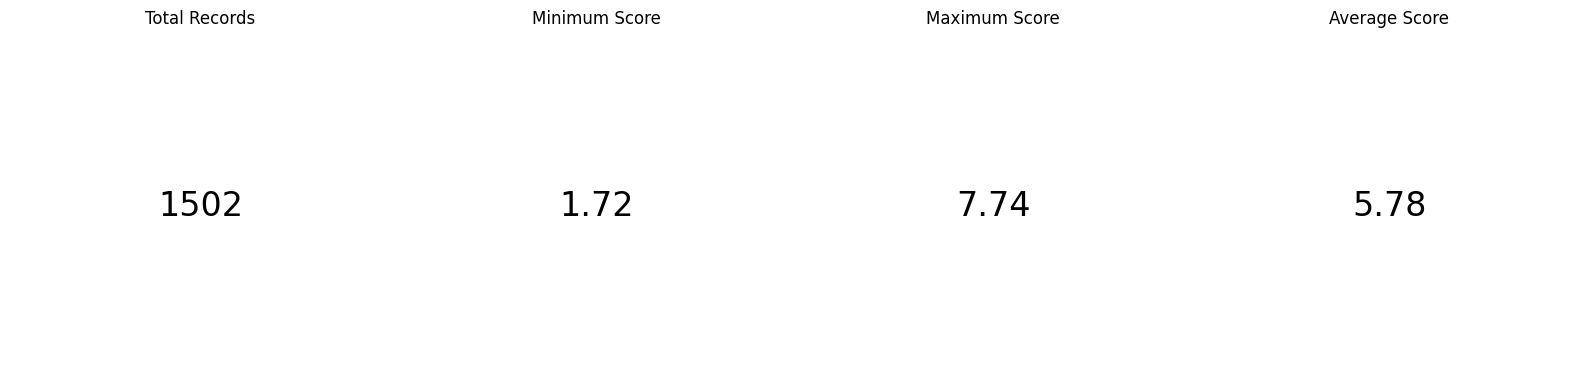

Dropdown(description='Country:', options=('All Countries', 'Afghanistan', 'Albania', 'Algeria', 'Angola', 'Arg…


FILTERED WORLD HAPPINESS DATA
Selected Country: Bolivia
Total Records: 10
Minimum Score: 5.78
Maximum Score: 5.8
Average Score: 5.8


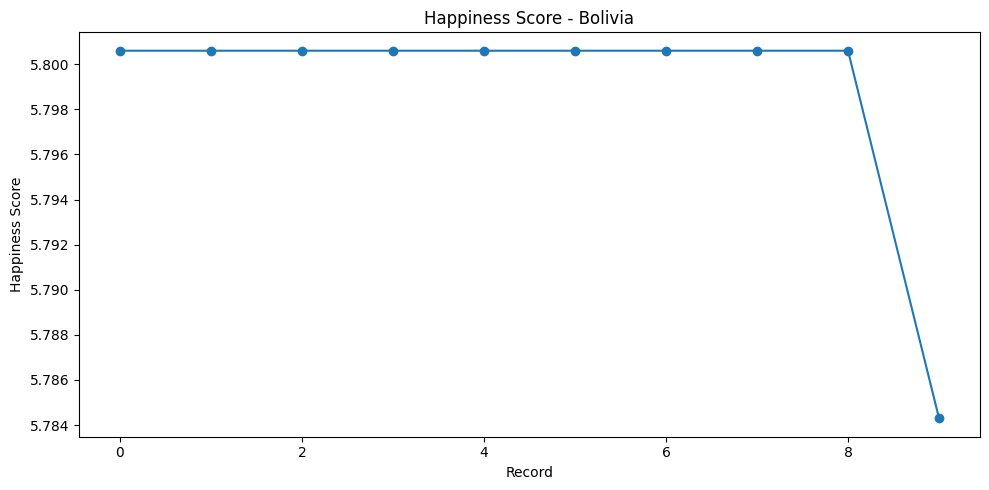

In [8]:
# ============================================================
# EXPERIMENT 6B
# KPI, SLICER AND DASHBOARD
# WORLD HAPPINESS DATASET 2015-2024
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
import ipywidgets as widgets


# ============================================================
# 2. KPI CALCULATIONS
# ============================================================

total_records = len(df)

minimum_score = df[score_column].min()

maximum_score = df[score_column].max()

average_score = df[score_column].mean()


print("============================================")
print("WORLD HAPPINESS KPI")
print("============================================")

print(
    "Total Records:",
    total_records
)

print(
    "Minimum Happiness Score:",
    round(minimum_score, 2)
)

print(
    "Maximum Happiness Score:",
    round(maximum_score, 2)
)

print(
    "Average Happiness Score:",
    round(average_score, 2)
)


# ============================================================
# 3. KPI CARD VISUALIZATION
# ============================================================

fig, axes = plt.subplots(
    1,
    4,
    figsize=(16,4)
)


axes[0].text(
    0.5,
    0.5,
    str(total_records),
    ha="center",
    va="center",
    fontsize=24
)

axes[0].set_title("Total Records")
axes[0].axis("off")


axes[1].text(
    0.5,
    0.5,
    f"{minimum_score:.2f}",
    ha="center",
    va="center",
    fontsize=24
)

axes[1].set_title("Minimum Score")
axes[1].axis("off")


axes[2].text(
    0.5,
    0.5,
    f"{maximum_score:.2f}",
    ha="center",
    va="center",
    fontsize=24
)

axes[2].set_title("Maximum Score")
axes[2].axis("off")


axes[3].text(
    0.5,
    0.5,
    f"{average_score:.2f}",
    ha="center",
    va="center",
    fontsize=24
)

axes[3].set_title("Average Score")
axes[3].axis("off")


plt.tight_layout()

plt.show()


# ============================================================
# 4. COUNTRY SLICER
# ============================================================

country_list = sorted(
    df[country_column]
    .dropna()
    .unique()
)


country_dropdown = widgets.Dropdown(
    options=["All Countries"] + country_list,
    description="Country:",
    value="All Countries"
)


display(country_dropdown)


# ============================================================
# 5. SLICER FUNCTION
# ============================================================

def update_dashboard(change):

    selected_country = change["new"]

    if selected_country == "All Countries":

        filtered_df = df.copy()

    else:

        filtered_df = df[
            df[country_column]
            == selected_country
        ]


    # --------------------------------------------------------
    # KPI VALUES
    # --------------------------------------------------------

    total = len(filtered_df)

    minimum = filtered_df[
        score_column
    ].min()

    maximum = filtered_df[
        score_column
    ].max()

    average = filtered_df[
        score_column
    ].mean()


    print("\n============================================")
    print("FILTERED WORLD HAPPINESS DATA")
    print("============================================")

    print(
        "Selected Country:",
        selected_country
    )

    print(
        "Total Records:",
        total
    )

    print(
        "Minimum Score:",
        round(minimum, 2)
    )

    print(
        "Maximum Score:",
        round(maximum, 2)
    )

    print(
        "Average Score:",
        round(average, 2)
    )


    # --------------------------------------------------------
    # DASHBOARD VISUALIZATION
    # --------------------------------------------------------

    plt.figure(figsize=(10,5))

    plt.plot(
        filtered_df[score_column].reset_index(drop=True),
        marker="o"
    )

    plt.title(
        "Happiness Score - " +
        selected_country
    )

    plt.xlabel("Record")

    plt.ylabel(
        "Happiness Score"
    )

    plt.tight_layout()

    plt.show()


# Connect slicer to dashboard
country_dropdown.observe(
    update_dashboard,
    names="value"
)